In [1]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 22.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4120 sha256=82393af8d9d528e538e45c42c5bd5d327f538160ebc68d670d37a3bc82ac511c
  Stored in directory: /root/.cache/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma


In [ ]:
import pandas as pd df = pd.read_csv('model_input.csv') print(df.shape) df.head()

SyntaxError: invalid syntax (971784256.py, line 1)

In [3]:
import pandas as pd
df = pd.read_csv('model_input.csv')
print(df.shape)
df.head()


(15868, 20)


,season,match_date,team,manager,manager_start_date,points,points_last_5,points_last_10,matches_into_tenure_so_far,tenure_days_so_far,league_position_before_match,points_to_date,gd_to_date,expectation_baseline,expectation_source,expectation_gap,event_observed,event_type,tenure_total_duration_days,tenure_end_date
0,506,03/01/2006,Man United,Alex Ferguson,06/11/1986,1,13.0,26.0,20,6998,1,44,23,NaN,no_prior_data,NaN,0,end_of_season,9704,01/06/2013
1,506,06/11/2005,Man United,Alex Ferguson,06/11/1986,3,7.0,18.0,10,6940,2,18,4,NaN,no_prior_data,NaN,0,end_of_season,9704,01/06/2013
2,506,17/12/2005,Man United,Alex Ferguson,06/11/1986,3,13.0,23.0,16,6981,1,34,15,NaN,no_prior_data,NaN,0,end_of_season,9704,01/06/2013
3,506,29/03/2006,Man United,Alex Ferguson,06/11/1986,3,15.0,22.0,30,7083,1,66,32,NaN,no_prior_data,NaN,0,end_of_season,9704,01/06/2013
4,506,29/10/2005,Man United,Alex Ferguson,06/11/1986,0,8.0,18.0,9,6932,5,18,7,NaN,no_prior_data,NaN,0,end_of_season,9704,01/06/2013


In [6]:
df['match_date'] = pd.to_datetime(df['match_date'], format='%d/%m/%Y')


In [7]:
survival_df = (
    df.sort_values('match_date')
      .groupby(['manager', 'team', 'manager_start_date'])
      .last()
      .reset_index()
)

survival_df = survival_df[[
    'manager', 'team', 'manager_start_date',
    'points_last_5', 'points_last_10',
    'league_position_before_match',
    'expectation_gap',
    'tenure_total_duration_days',
    'event_observed', 'event_type'
]]

print(survival_df.shape)
survival_df.head()

(283, 10)


,manager,team,manager_start_date,points_last_5,points_last_10,league_position_before_match,expectation_gap,tenure_total_duration_days,event_observed,event_type
0,Aidy Boothroyd,Watford,29/03/2005,7.0,8.0,20,-3.0,1315,0,non_pl_departure
1,Aitor Karanka,Middlesbrough,13/11/2013,2.0,7.0,12,5.0,1219,1,sacked
2,Alain Perrin,Portsmouth,07/04/2005,5.0,10.0,10,NaN,231,1,sacked
3,Alan Curbishley,Charlton,24/07/1991,4.0,12.0,12,NaN,5402,0,end_of_season
4,Alan Curbishley,West Ham,13/12/2006,5.0,9.0,9,1.0,630,0,mid_season_not_sacked


In [8]:
# Check for managers/clubs with multiple suspiciously-close start dates
# (could indicate the same real tenure getting split into two)
check = df.groupby(['manager', 'team'])['manager_start_date'].nunique().reset_index()
check = check[check['manager_start_date'] > 1]
print(check.shape)
check

(7, 3)


,manager,team,manager_start_date
48,Chris Wilder,Sheffield United,2
58,David Moyes,Everton,2
61,David Moyes,West Ham,2
110,José Mourinho,Chelsea,2
181,Paul Heckingbottom,Sheffield United,2
191,Quique Sánchez Flores,Watford,2
210,Roy Hodgson,Crystal Palace,2


In [9]:
survival_df[['tenure_total_duration_days', 'event_observed', 'expectation_gap']].isnull().sum()

,0
tenure_total_duration_days,0
event_observed,0
expectation_gap,8


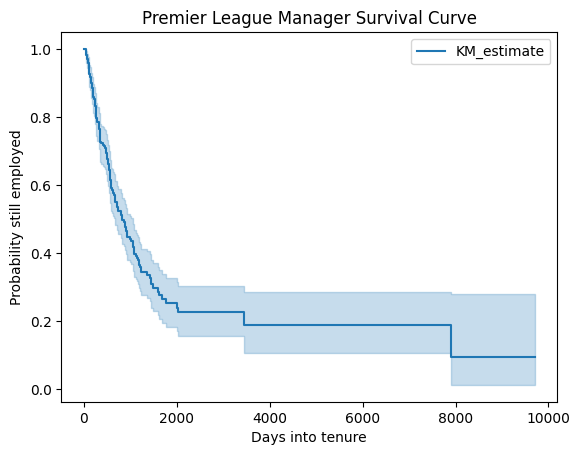

Median survival time: 827.0 days


In [10]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()
kmf.fit(durations=survival_df['tenure_total_duration_days'],
        event_observed=survival_df['event_observed'])

kmf.plot_survival_function()
plt.title('Premier League Manager Survival Curve')
plt.xlabel('Days into tenure')
plt.ylabel('Probability still employed')
plt.show()

print(f"Median survival time: {kmf.median_survival_time_} days")

In [11]:
from lifelines import CoxPHFitter

cox_df = survival_df.dropna(subset=['expectation_gap']).copy()

cox_df = cox_df[[
    'tenure_total_duration_days', 'event_observed',
    'points_last_5', 'expectation_gap', 'league_position_before_match'
]]

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='tenure_total_duration_days', event_col='event_observed')

cph.print_summary()

TypeError: NaNs were detected in the dataset. Try using pd.isnull to find the problematic values.

In [12]:
cox_df.isnull().sum()

,0
tenure_total_duration_days,0
event_observed,0
points_last_5,2
expectation_gap,0
league_position_before_match,0


In [13]:
cox_df = cox_df.dropna()
print(cox_df.shape)

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='tenure_total_duration_days', event_col='event_observed')
cph.print_summary()

(273, 5)


<lifelines.CoxPHFitter: fitted with 273 total observations, 124 right-censored observations>
             duration col = 'tenure_total_duration_days'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 273
number of events observed = 149
   partial log-likelihood = -684.48
         time fit was run = 2026-09-15 11:14:07 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
points_last_5                -0.21      0.81      0.04           -0.28           -0.14                0.75                0.87
expectation_gap               0.02      1.02      0.02           -0.02            0.06                0.98                1.06
league_position_before_match -0.06      0.94      0.02           -0.11           -0.02                0.90                0.98

                              cmp to     z      p  -log2(p)
covariate                                                  
points_last_5                   0.00 -5.74 <0.005     26.66
expectation_gap                 0.00  1.08   0.28      1.84
league_position_before_match    0.00 -2.75   0.01      7.39
---
Concordance = 0.64
Partial AIC = 1374.95
log-likelihood ratio test = 55.16 on 3 df
-log2(p) of ll-ratio test = 37.19


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'league_position_before_match' failed the non-proportional test: p-value is 0.0346.

   Advice 1: the functional form of the variable 'league_position_before_match' might be incorrect.
That is, there may be non-linear terms missing. The proportional hazard test used is very sensitive
to incorrect functional forms. See documentation in link [D] below on how to specify a functional
form.

   Advice 2: try binning the variable 'league_position_before_match' using pd.cut, and then specify
it in `strata=['league_position_before_match', ...]` in the call in `.fit`. See documentation in
link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.rea

[[<Axes: xlabel='rank-transformed time\n(p=0.3498)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2337)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7851)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7908)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0346)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0492)'>]]

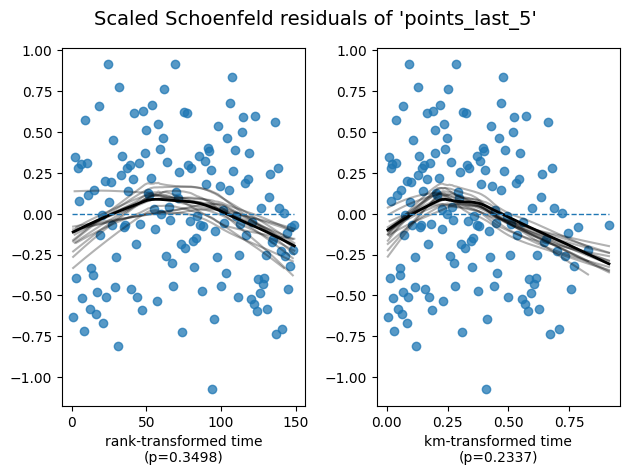

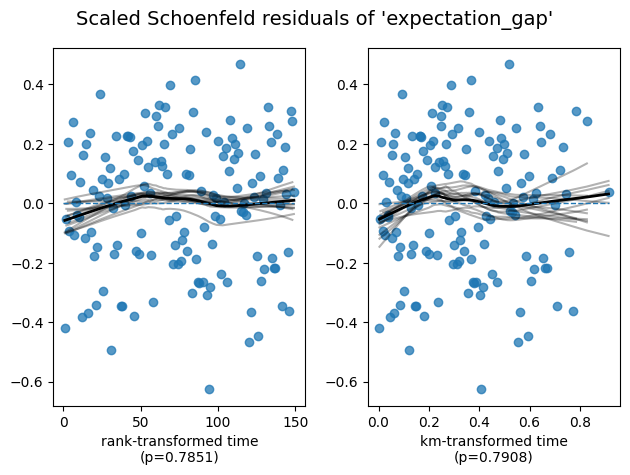

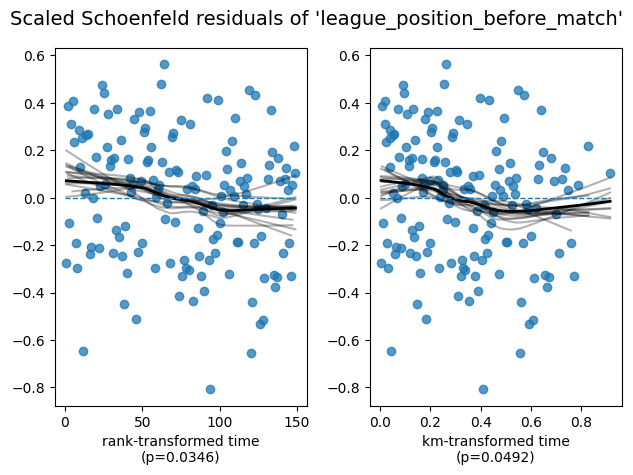

In [14]:
cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=True)